In [113]:
import pandas as pd

df_tayara = pd.read_csv("../data/raw/tayara.csv")
df_mubawab = pd.read_csv("../data/raw/mubawab.csv")
df_immobilier = pd.read_csv("../data/raw/immobilier.csv")

# 1.Data Preprocessing


In [114]:

cities_mubawab = df_mubawab.iloc[:, -1].str.strip()
unique_cities_mubawab = sorted(cities_mubawab.unique())

cities_tayara = df_tayara.iloc[:, -1].str.strip()
unique_cities_tayara = sorted(cities_tayara.unique())

cities_immobilier = df_immobilier.iloc[:, -1].str.strip()
unique_cities_immobilier = sorted(
    df_immobilier.iloc[:, -1]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

print(unique_cities_mubawab)
print(unique_cities_tayara)
print(unique_cities_immobilier)


['Aghir', 'Ajim', 'Akouda', 'Al-Qayrawan', 'Ariana', 'Aïn Draham', 'Barraket Essahel', 'Bekalta', 'Ben Arous', 'Beni Khalled', 'Beni Khiar', 'Bir Bouregba', 'Bizerte', 'Bizerte Nord', 'Bizerte Sud', 'Bou Arada', 'Bou Argoub', 'Bou Salem', 'Bouficha', 'Boumhel Bassatine', 'Béja', 'Carthage', 'Chebba', 'Cité De La Plage 1', 'Cité El Khadra', 'Cité El Menzah', 'Cité Ennarjes 1', 'Cité Ennouzha', 'Cité Ezzouhour 2', 'Cité Ezzouhour 3', 'Cité Hached', 'Cité Jaouhara', 'Cité Presidentielle', 'Cité Taieb Mhiri', 'Dar Châabane', 'Djerba', 'Douar Hicher', 'Douz', 'El Ain', 'El Alia', 'El Aouina', 'El Hamma', 'El Haouaria', 'El Hrairia', 'El Kabaria', 'El Ksar', 'El Maamoura', 'El Menzah', 'El Mida', 'El Mourouj', 'El Omrane', 'El Omrane Superieur', 'El Ouardia', 'Enfidha', 'Essouassi', 'Ettadhamen', 'Ettahrir', 'Ezzahra', 'Fouchana', 'Gabès', 'Gabès Sud', 'Gafsa', 'Gafsa Sud', 'Ghar El Melh', 'Grombalia', 'Hammam Chatt', 'Hammam El Ghezaz', 'Hammam Ghezèze', 'Hammam Lif', 'Hammam Sousse', 'Hamm

### Data Inspection


In [115]:
df_mubawab.info()
df_mubawab.head()

df_tayara.info()
df_tayara.head()

df_immobilier.info()
df_immobilier.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6587 entries, 0 to 6586
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   chambres          6587 non-null   int64  
 1   prix              6587 non-null   float64
 2   source            6587 non-null   object 
 3   surface           6587 non-null   float64
 4   titre             6587 non-null   object 
 5   type_bien         6587 non-null   object 
 6   type_transaction  6587 non-null   object 
 7   ville             6587 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 411.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1921 entries, 0 to 1920
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   chambres          1921 non-null   int64  
 1   prix              1921 non-null   float64
 2   source            1921 non-null   object 
 3   surface       

,chambres,prix,source,surface,titre,type_bien,type_transaction,ville
0,2,1600.0,immobilier,80.0,Au coeur de la marsa,Appart,À Vendre,Tunis
1,2,1600.0,immobilier,140.0,Appartement rayen à lannée hammamet,Appart,À Vendre,Nabeul
2,2,900.0,immobilier,100.0,"Bureau s2 à lafayette, tunis.",Appart,À Vendre,Tunis
3,2,800.0,immobilier,80.0,"Superbes appartements s2 neufs à gremda km 7,5",Appart,À Vendre,Sfax
4,4,275.0,immobilier,122.0,À vendre appartement s3 la marsa,Appart,À Vendre,Tunis


###  Merge

In [116]:
import pandas as pd

df_all = pd.concat(
    [df_mubawab, df_tayara, df_immobilier],
    ignore_index=True
)

print(df_all.shape)


(9234, 8)


### Normalize City Names

In [117]:
import re
import unidecode

def normalize_city(city):
    if not isinstance(city, str):
        return None
    city = city.strip().lower()
    city = unidecode.unidecode(city)
    city = re.sub(r"\s+", " ", city)
    return city

df_all["city_raw"] = df_all["ville"]
df_all["city_norm"] = df_all["city_raw"].apply(normalize_city)


### City to Government mapping

In [118]:
CITY_TO_GOV = {
    # TUNIS
    "tunis": "Tunis",
    "la marsa": "Tunis",
    "carthage": "Tunis",
    "le bardo": "Tunis",
    "le kram": "Tunis",
    "la goulette": "Tunis",
    "el omrane": "Tunis",
    "el omrane superieur": "Tunis",
    "el kabaria": "Tunis",
    "el hrairia": "Tunis",
    "sidi hassine": "Tunis",

    # ARIANA
    "ariana": "Ariana",
    "raoued": "Ariana",
    "sidi thabet": "Ariana",
    "el menzah": "Ariana",
    "ennasr": "Ariana",

    # BEN AROUS
    "ben arous": "Ben Arous",
    "benarous": "Ben Arous",
    "rades": "Ben Arous",
    "ezzahra": "Ben Arous",
    "boumhel bassatine": "Ben Arous",
    "hammam chatt": "Ben Arous",
    "hammam lif": "Ben Arous",

    # MANOUBA
    "la manouba": "Manouba",
    "lamanouba": "Manouba",
    "douar hicher": "Manouba",

    # NABEUL
    "nabeul": "Nabeul",
    "hammamet": "Nabeul",
    "hammamet nord": "Nabeul",
    "korba": "Nabeul",
    "kelibia": "Nabeul",
    "takelsa": "Nabeul",
    "soliman": "Nabeul",
    "dar chaabane": "Nabeul",

    # SOUSSE
    "sousse": "Sousse",
    "sahloul": "Sousse",
    "khezama est": "Sousse",
    "khezama ouest": "Sousse",
    "jaouhara": "Sousse",
    "tantana": "Sousse",
    "hammam sousse": "Sousse",

    # SFAX
    "sfax": "Sfax",
    "sfax sud": "Sfax",
    "sfax ouest": "Sfax",

    # MONASTIR
    "monastir": "Monastir",
    "jemmal": "Monastir",
    "ksar hellal": "Monastir",

    # MAHDIA
    "mahdia": "Mahdia",
    "chebba": "Mahdia",

    # GABES
    "gabes": "Gabes",
    "gabs": "Gabes",

    # MEDNINE
    "medenine": "Mednine",
    "mdenine": "Mednine",
    "djerba": "Mednine",
    "houmt souk": "Mednine",
    "midoun": "Mednine",

    # KAIROUAN
    "kairouan": "Kairouan",

    # KASSERINE
    "kasserine": "Kasserine",

    # GAFSA
    "gafsa": "Gafsa",

    # TOZEUR
    "tozeur": "Tozeur",

    # ZAGHOUAN
    "zaghouan": "Zaghouan",
}


In [119]:
df_all["governorate"] = df_all["city_norm"].map(CITY_TO_GOV)


### Drop ligns with empty column values

In [120]:
before = df_all.shape[0]
df_all = df_all.dropna(subset=["governorate", "surface", "prix", "chambres"])
after = df_all.shape[0]

print(f"Dropped {before - after} rows")


Dropped 1894 rows


In [121]:
df_all["governorate"].value_counts()


governorate
Tunis        2779
Nabeul       1556
Ariana       1169
Sousse        789
Ben Arous     369
Mednine       231
Manouba       109
Monastir      100
Sfax           95
Mahdia         84
Kairouan       39
Zaghouan        6
Gafsa           4
Gabes           4
Kasserine       3
Tozeur          3
Name: count, dtype: int64

### Dropping columns we don't need


In [122]:
#drop type_transaction column as they are all a vendre
df_all = df_all.drop(columns=["type_transaction"])


In [123]:
#drop city_raw column
df_all = df_all.drop(columns=["city_raw"])

In [124]:
# drop source column
df_all = df_all.drop(columns=["source"])


### Renaming and saving final csv

In [125]:

df_clean = df_all.rename(columns={
    "prix": "price",
    "surface": "surface",
    "chambres": "rooms",
    "type_bien": "property_type",
})

df_clean = df_clean[
    [
        "price",
        "surface",
        "rooms",
        "governorate",
        "property_type",
    ]
]
df_clean.info()
df_clean.to_csv("../data/clean/clean_housing_tunisia.csv", index=False)



<class 'pandas.core.frame.DataFrame'>
Index: 7340 entries, 0 to 9233
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          7340 non-null   float64
 1   surface        7340 non-null   float64
 2   rooms          7340 non-null   int64  
 3   governorate    7340 non-null   object 
 4   property_type  7340 non-null   object 
dtypes: float64(2), int64(1), object(2)
memory usage: 344.1+ KB


# 2.EDA


In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/clean/clean_housing_tunisia.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7340 entries, 0 to 7339
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          7340 non-null   float64
 1   surface        7340 non-null   float64
 2   rooms          7340 non-null   int64  
 3   governorate    7340 non-null   object 
 4   property_type  7340 non-null   object 
dtypes: float64(2), int64(1), object(2)
memory usage: 286.8+ KB


,price,surface,rooms
count,7.340000e+03,7.340000e+03,7.340000e+03
mean,4.332466e+06,1.339924e+04,2.051215e+02
std,1.405801e+08,1.119430e+06,1.366865e+04
min,1.200000e+00,-1.020000e+02,-3.000000e+00
25%,2.499728e+05,1.040000e+02,2.000000e+00
50%,4.150000e+05,1.550000e+02,3.000000e+00
75%,7.800000e+05,3.000000e+02,4.000000e+00
max,1.111111e+10,9.590518e+07,1.111111e+06


### Description of the target (price)


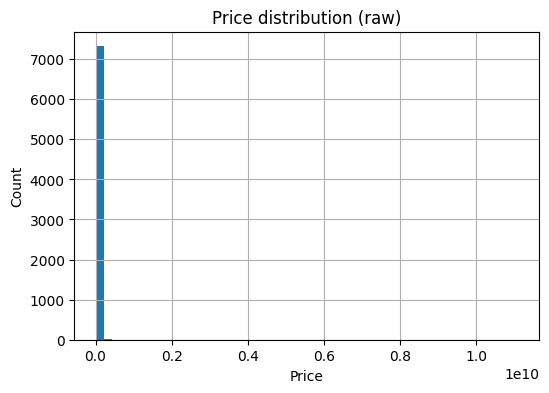

In [127]:
plt.figure(figsize=(6,4))
df["price"].hist(bins=50)
plt.title("Price distribution (raw)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()


### Log transform price

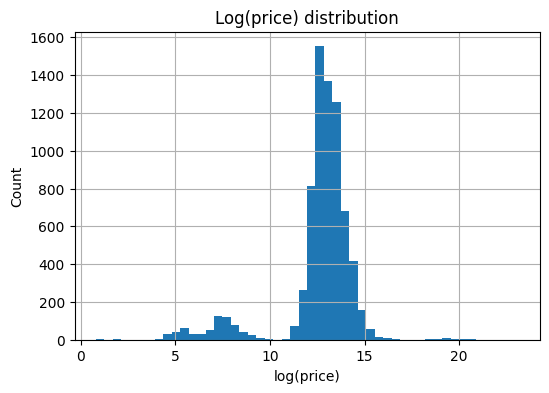

In [128]:
df["log_price"] = np.log1p(df["price"])

plt.figure(figsize=(6,4))
df["log_price"].hist(bins=50)
plt.title("Log(price) distribution")
plt.xlabel("log(price)")
plt.ylabel("Count")
plt.show()


### Surface and room inspection

#### Surface

In [129]:
df["surface"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])


count    7.340000e+03
mean     1.339924e+04
std      1.119430e+06
min     -1.020000e+02
50%      1.550000e+02
90%      5.052000e+02
95%      6.700000e+02
99%      1.264150e+03
max      9.590518e+07
Name: surface, dtype: float64

C:\Users\Maryem Belghouthi\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


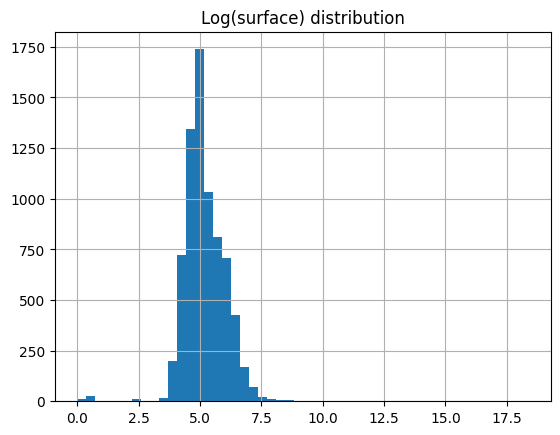

In [130]:
df["log_surface"] = np.log1p(df["surface"])

df["log_surface"].hist(bins=50)
plt.title("Log(surface) distribution")
plt.show()

#### Rooms

In [131]:
df["rooms"].value_counts().sort_index()


rooms
-3             1
-2             2
-1             8
 0            42
 1           735
 2          1898
 3          2176
 4          1225
 5           634
 6           260
 7           122
 8            84
 9            58
 10           25
 11           12
 12           20
 13            7
 14            6
 15            2
 16            6
 17            1
 19            1
 20            4
 24            2
 25            1
 28            1
 38            1
 70            1
 100           1
 111           1
 300           1
 370000        1
 1111111       1
Name: count, dtype: int64

### Categorical Variables

#### Governorate

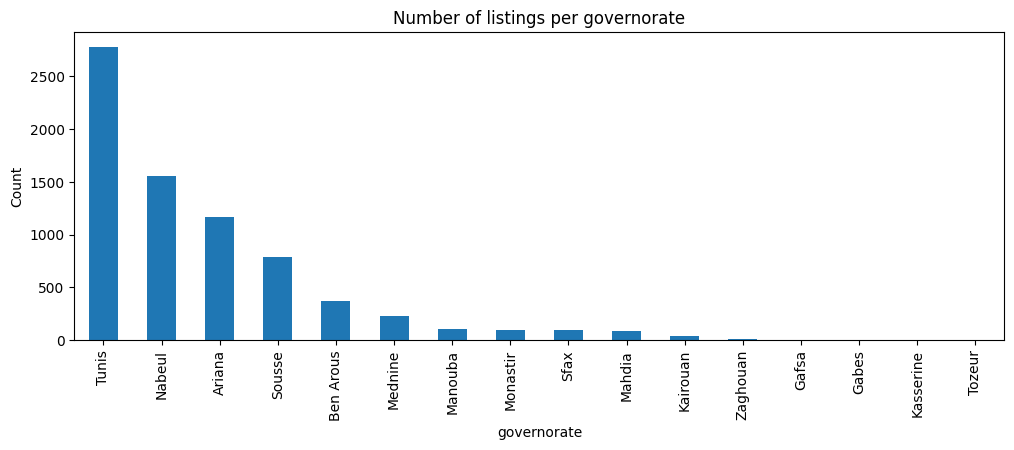

In [132]:
plt.figure(figsize=(12,4))
df["governorate"].value_counts().plot(kind="bar")
plt.title("Number of listings per governorate")
plt.ylabel("Count")
plt.show()

#### Property type

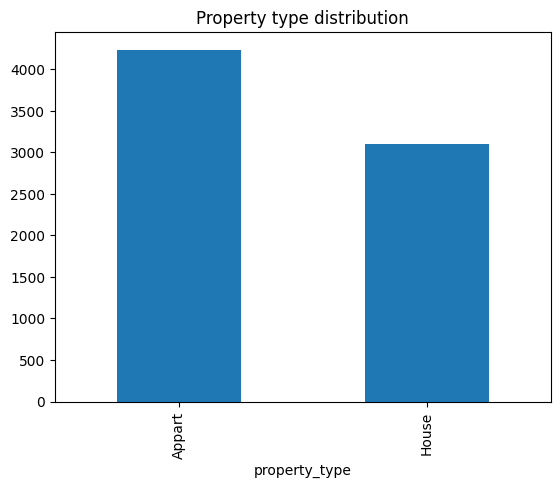

In [133]:
df["property_type"].value_counts().plot(kind="bar")
plt.title("Property type distribution")
plt.show()


### Relationships

#### Price vs Surface (raw)

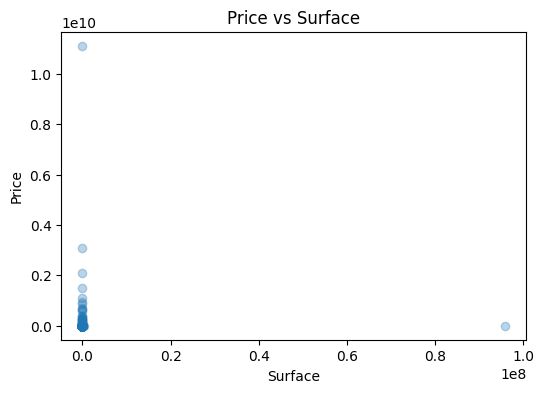

In [134]:
plt.figure(figsize=(6,4))
plt.scatter(df["surface"], df["price"], alpha=0.3)
plt.xlabel("Surface")
plt.ylabel("Price")
plt.title("Price vs Surface")
plt.show()


#### Log to log relationship

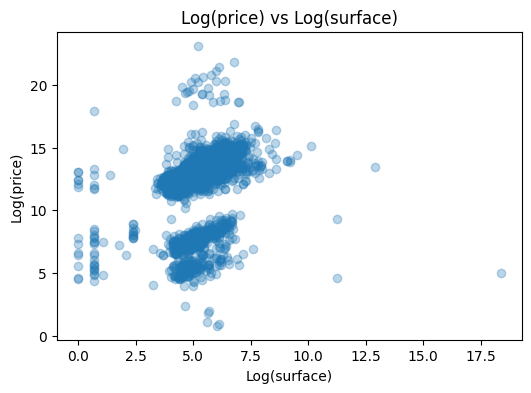

In [135]:
plt.figure(figsize=(6,4))
plt.scatter(df["log_surface"], df["log_price"], alpha=0.3)
plt.xlabel("Log(surface)")
plt.ylabel("Log(price)")
plt.title("Log(price) vs Log(surface)")
plt.show()


#### Price by government

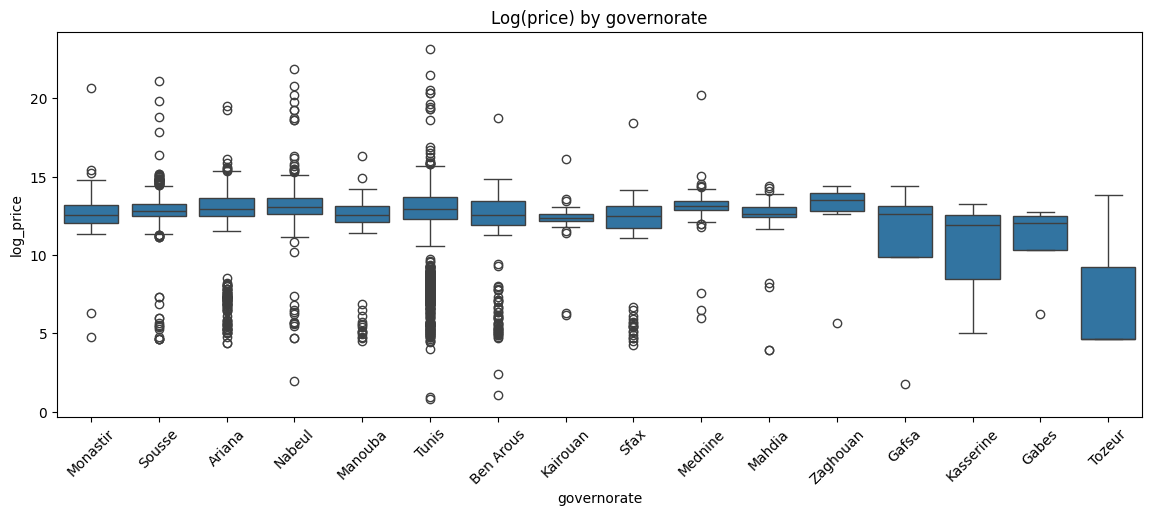

In [136]:
plt.figure(figsize=(14,5))
sns.boxplot(x="governorate", y="log_price", data=df)
plt.xticks(rotation=45)
plt.title("Log(price) by governorate")
plt.show()


# Cleaning unreasonable/impossible data

In [137]:
df = df[(df["price"] > 10000) & (df["price"] < 1e7)]

df = df[(df["surface"] > 10) & (df["surface"] < 5000)]
df = df[(df["rooms"] >= 1) & (df["rooms"] <= 10)]
df["log_price"] = np.log1p(df["price"])
df["log_surface"] = np.log1p(df["surface"])
df[["price", "surface"]].describe(percentiles=[0.95, 0.99])


,price,surface
count,6.530000e+03,6530.000000
mean,6.793918e+05,242.932496
std,6.937952e+05,258.746536
min,1.111100e+04,27.000000
50%,4.500000e+05,155.000000
95%,1.900000e+06,650.000000
99%,3.500000e+06,1200.000000
max,9.000000e+06,4650.000000


In [138]:
df.to_csv("../data/clean/clean_housing_tunisia_model_ready.csv", index=False)


# 3.Modeling

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/clean/clean_housing_tunisia_model_ready.csv")

df.head()


### Define Target and features

In [140]:
df["log_price"] = np.log1p(df["price"])

X = df[["surface", "rooms", "governorate", "property_type"]]
y = df["log_price"]


### Encode Categorical Values

In [141]:
X = pd.get_dummies(
    X,
    columns=["governorate", "property_type"],
    drop_first=True
)


### Train/Test Split

In [142]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Linear Regression

In [143]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression RMSE:", rmse)
print("Linear Regression R²:", r2)


Linear Regression RMSE: 0.5529072592130946
Linear Regression R²: 0.5168401652152879


## Random Forest

In [144]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)


Random Forest RMSE: 0.5119735817415091
Random Forest R²: 0.5857320421308262


### Model Comparison

In [145]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [rmse, rmse_rf],
    "R2": [r2, r2_rf]
})

results


,Model,RMSE,R2
0,Linear Regression,0.552907,0.516840
1,Random Forest,0.511974,0.585732


#### Random forest hyperparameter tuning

In [146]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 4],
    'n_jobs': [-1]
}

# Instantiate Random Forest model
rf = RandomForestRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=2)

# Fit grid search
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best hyperparameters:", grid_search.best_params_)

# Best score (RMSE)
print("Best RMSE:", np.sqrt(-grid_search.best_score_))


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best hyperparameters: {'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 500, 'n_jobs': -1}
Best RMSE: 0.6956980637023491


### Changing random forest hyperparameters


In [147]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42,
    min_samples_leaf=4,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest RMSE: 0.48188408581291187
Random Forest R²: 0.6329954840137785


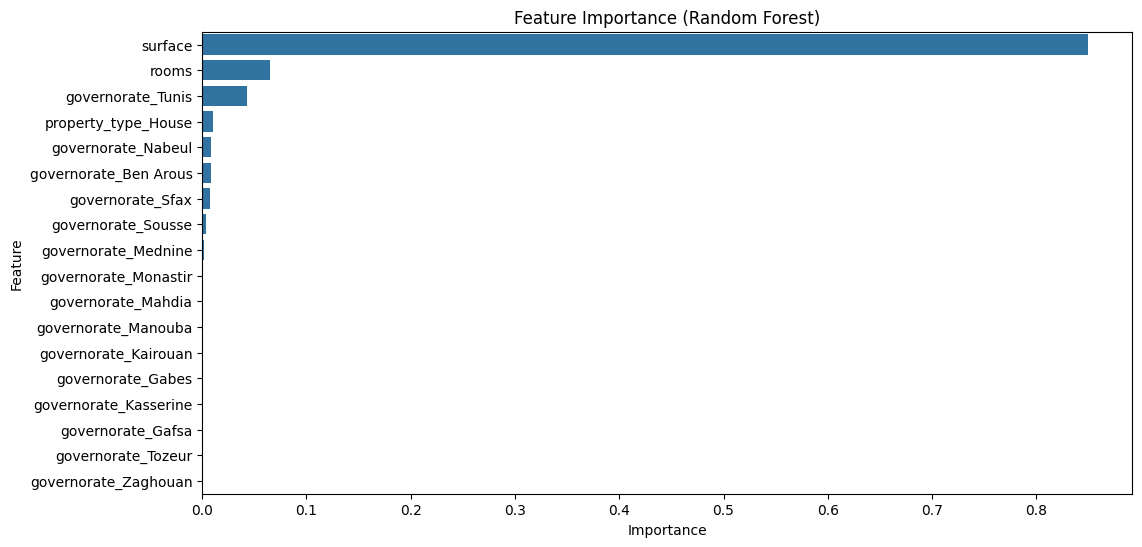

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf.feature_importances_

# Create a DataFrame for easy plotting
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="Importance", y="Feature", data=feat_importance)
plt.title("Feature Importance (Random Forest)")
plt.show()


## XGBoost

In [149]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    n_estimators=500,          
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Metrics
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R²:", r2_xgb)


XGBoost RMSE: 0.4801743088909236
XGBoost R²: 0.6355952073021035


# 4.Tracking

In [150]:
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load your data
df = pd.read_csv("../data/clean/clean_housing_tunisia_model_ready.csv")

# Feature engineering (optional, can toggle per run)
df["rooms_per_surface"] = df["rooms"] / df["surface"]
df["surface_squared"] = df["surface"] ** 2

# Pick features
X = df[
    ["surface", "surface_squared", "rooms", "rooms_per_surface",
     "governorate", "property_type"]
]
X = pd.get_dummies(X, columns=["governorate", "property_type"], drop_first=True)
y = df["log_price"]

# Split function (toggle between random or grouped)
def get_split(X, y, method="random"):
    if method == "grouped":
        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        for train_idx, test_idx in gss.split(X, y, groups=df["governorate"]):
            return X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]
    else:
        return train_test_split(X, y, test_size=0.2, random_state=42)

# Models to test
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=300, max_depth=None, min_samples_leaf=1, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective="reg:squarederror", random_state=42, n_jobs=-1
    )
}
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("house-price-tunisia")

# Iterate over models and split types
for split_method in ["random", "grouped"]:
    X_train, X_test, y_train, y_test = get_split(X, y, method=split_method)
    
    for name, model in models.items():
        run_name = f"{name}_{split_method}_split"
        with mlflow.start_run(run_name=run_name):
            # Train
            model.fit(X_train, y_train)
            
            # Predict
            y_pred = model.predict(X_test)
            
            # Metrics
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            
            # Log metrics and params
            mlflow.log_metric("rmse", rmse)
            mlflow.log_metric("r2", r2)
            mlflow.log_param("model", name)
            mlflow.log_param("split", split_method)
            mlflow.log_param("features", list(X.columns))
            
            # Log model
            
            mlflow.sklearn.log_model(model, name="model", skops_trusted_types=["sklearn.tree._tree.Tree", "xgboost.core.Booster", "xgboost.sklearn.XGBRegressor"])

2026/09/22 23:29:06 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/09/22 23:29:45 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/09/22 23:30:48 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make

# 5.Model_registry

### Import mlflow client

In [151]:
from mlflow.tracking import MlflowClient
import pickle

client = MlflowClient()
mlflow.set_tracking_uri("sqlite:///mlflow.db")
client = mlflow.tracking.MlflowClient()


### Take the best run

In [152]:
runs = client.search_runs(experiment_ids=["0"])  # or your experiment's actual ID
for r in runs:
    print(r.info.run_id, r.info.status)

In [153]:
import os; print(os.path.exists('mlflow.db'), os.getcwd())

True c:\Users\Maryem Belghouthi\House-Price-Prediction\Notebooks


In [154]:
client.search_experiments()

[<Experiment: artifact_location='file:///c:/Users/Maryem Belghouthi/House-Price-Prediction/Notebooks/mlruns/1', creation_time=1790091190203, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790091190203, lifecycle_stage='active', name='house-price-tunisia', tags={}, trace_location=None, workspace='default'>,
 <Experiment: artifact_location='file:///c:/Users/Maryem Belghouthi/House-Price-Prediction/Notebooks/mlruns/0', creation_time=1790091190180, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1790091190180, lifecycle_stage='active', name='Default', tags={}, trace_location=None, workspace='default'>]

In [155]:
runs = client.search_runs(experiment_ids=["1"])
for r in runs:
    print(r.info.run_id, r.info.status, r.data.metrics)

b5bd05652460434696c3c7fb8d784220 FINISHED {'rmse': 0.6030611036680291, 'r2': 0.4702350099245953}
dade76c8c4114fabbce779ccdcd6133b FINISHED {'rmse': 0.5965162774734609, 'r2': 0.481671348491986}
67df59acf023496f9a974d0a06aba7cf FINISHED {'rmse': 0.6668505936969419, 'r2': 0.3522346664105551}
3b43a4c3168e44259d0c52e459d9a1bc FINISHED {'rmse': 0.4853422398277551, 'r2': 0.6277091003381812}
b461726e39874e9e867d74ad598e2c00 FINISHED {'rmse': 0.5121832104713469, 'r2': 0.5853927267917565}
1c8c788db41e4f7298e42c576456ff01 FINISHED {'rmse': 0.5156672235799916, 'r2': 0.5797329937838012}
4a0d6082521f4d6595f6092bd0fa9dbc FINISHED {'rmse': 0.6030611036680291, 'r2': 0.4702350099245953}
abda6440df1847dd846cfb19113f2b31 FINISHED {'rmse': 0.5965162774734609, 'r2': 0.4816713484919861}
8fb0eb5bcf3d4a03ab474c651fcf968b FINISHED {'rmse': 0.6668505936969419, 'r2': 0.3522346664105551}
ece9af47030f477f86d852e3e238f202 FINISHED {'rmse': 0.4853422398277551, 'r2': 0.6277091003381812}
b98a72c4bae849f5bda2b1fac0a8e6b

In [156]:
# Choose best run
best_run_id = "ece9af47030f477f86d852e3e238f202"
best_run = client.get_run(best_run_id)

# Extract feature columns logged in this run
feature_columns = best_run.data.params["features"]
print("Feature columns of best model:", feature_columns)
import os
os.makedirs("artifacts", exist_ok=True)

with open("artifacts/best_model_features.pkl", "wb") as f:
    pickle.dump(feature_columns, f)
# Save feature columns for FastAPI / registry
with open("artifacts/best_model_features.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

# Log them as artifact in MLflow
client.log_artifact(best_run_id, "artifacts/best_model_features.pkl", artifact_path="model_artifacts")

Feature columns of best model:

 ['surface', 'surface_squared', 'rooms', 'rooms_per_surface', 'governorate_Ben Arous', 'governorate_Gabes', 'governorate_Gafsa', 'governorate_Kairouan', 'governorate_Kasserine', 'governorate_Mahdia', 'governorate_Manouba', 'governorate_Mednine', 'governorate_Monastir', 'governorate_Nabeul', 'governorate_Sfax', 'governorate_Sousse', 'governorate_Tozeur', 'governorate_Tunis', 'governorate_Zaghouan', 'property_type_House']


### Register the best model

In [157]:


# Register model in the Model Registry
model_name = "HousePriceModel"

# Create the registered model 
try:
    client.create_registered_model(model_name)
except:
    print("Model already exists, skipping creation.")

# Create a new version for this run
version = client.create_model_version(
    name=model_name,
    source=f"runs:/{best_run_id}/model",
    run_id=best_run_id
)

print(f"Registered model version: {version.version}")


Model already exists, skipping creation.
Registered model version: 2


### Promote the version to production 

In [158]:
client.transition_model_version_stage(
    name=model_name,
    version=version.version,
    stage="Production"
)

print(f"Model version {version.version} is now in Production")




Model version 2 is now in Production


C:\Users\Maryem Belghouthi\AppData\Local\Temp\ipykernel_12376\2596384108.py:1: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(
